In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_nonlinear_pendulum_rhs(*default_params['nonlinear_pendulum'])
x0 = default_x0['nonlinear_pendulum']

dt = 0.01
t_span = (0, 50)

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

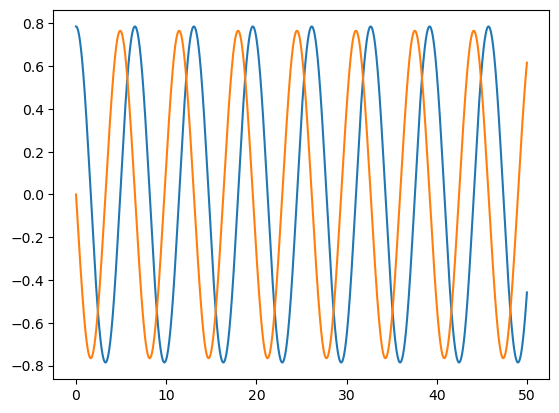

In [3]:
x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)

plt.plot(t_eval, x_train.T)
plt.show()

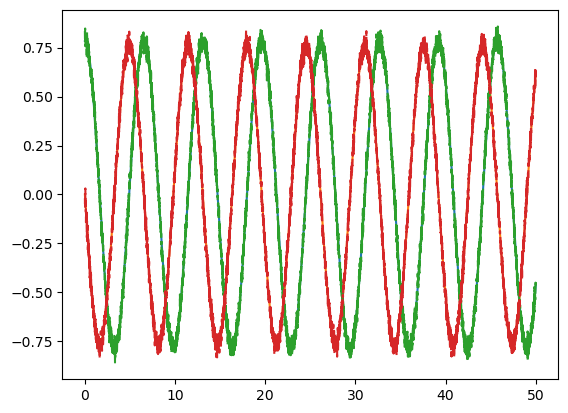

In [4]:
x_train_noisy = add_noise_to_data(x_train, 0.05)

plt.plot(t_eval, x_train.T)
plt.plot(t_eval, x_train_noisy.T, '--')
plt.show()

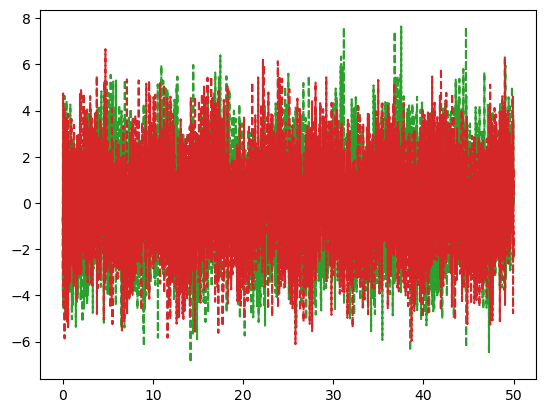

In [5]:
# generate the true derivative
x_dot_true = lotka_volterra_rhs(t_eval, x_train)

x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)

plt.plot(t_eval, x_dot_true.T)
plt.plot(t_eval, x_dot_approx.T, '--')
plt.show()

In [14]:
# generate models for different noise levels

threshold = 0.05

noise_levels = [0, 0.0001, 0.001, 0.01, 0.1, 1]

models = []
ps_models = []
for noise_level in tqdm(noise_levels):
    # generate noisy data
    x_train_noisy = add_noise_to_data(x_train, noise_level)
    
    # generate the derivative of the noisy data
    # NOTE: we can change the kind of derivative and the parameters of the derivative method!
    x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)

    # create and fit a SINDy model
    model = SINDyModel(n_state_vars=2, threshold=threshold, poly_order=2, n_frequencies=5, use_ridge=False)
    model.fit(x_train_noisy, x_dot_approx)
    models.append(model)

    import pysindy as ps
    ps_model = ps.SINDy(optimizer=ps.STLSQ(threshold=0.05, alpha=0.00),
                        feature_library=ps.GeneralizedLibrary([ps.PolynomialLibrary(degree=2), ps.FourierLibrary(n_frequencies=5)]))
    ps_model.fit(x_train_noisy.T, x_dot=x_dot_approx.T)
    ps_models.append(ps_model)


# print the models
for i in range(len(noise_levels)):
    print(f"noise level: {noise_levels[i]}")
    print("my model:")
    models[i].print(decimals=3)
    print("PySINDy model:")
    ps_models[i].print()
    print()

100%|██████████| 6/6 [00:00<00:00, 16.74it/s]

noise level: 0
my model:
x0' = + 299488.007 1 + -74.485 x0 + -26.887 x1 + -11793.864 x0^2 + -91757.313 x1^2 + 125.892 sin(1*x0) + -34974.261 cos(1*x0) + 47.068 sin(1*x1) + -304005.583 cos(1*x1) + -37.517 sin(2*x0) + 3007.657 cos(2*x0) + -13.967 sin(2*x1) + 42511.392 cos(2*x1) + 10.065 sin(3*x0) + 129.125 cos(3*x0) + 3.719 sin(3*x1) + -6753.790 cos(3*x1) + -1.853 sin(4*x0) + -149.986 cos(4*x0) + -0.677 sin(4*x1) + 762.398 cos(4*x1) + 0.169 sin(5*x0) + 23.748 cos(5*x0) + 0.061 sin(5*x1) + -38.727 cos(5*x1) 
x1' = + -7399.698 1 + 47.275 x1 + -46498.879 x0^2 + 48727.589 x1^2 + -1.000 sin(1*x0) + -156169.815 cos(1*x0) + -79.856 sin(1*x1) + 165086.531 cos(1*x1) + 22822.844 cos(2*x0) + 23.753 sin(2*x1) + -24784.210 cos(2*x1) + -3952.685 cos(3*x0) + -6.352 sin(3*x1) + 4500.767 cos(3*x1) + 522.377 cos(4*x0) + 1.164 sin(4*x1) + -638.601 cos(4*x1) + -36.130 cos(5*x0) + -0.105 sin(5*x1) + 48.651 cos(5*x1) 
PySINDy model:
(x0)' = 299487.979 1 + -74.485 x0 + -26.887 x1 + -11793.869 x0^2 + -91757.299